# ISPRA RU costi e kg per abitante - v0

## Domanda

I territori che producono meno rifiuti urbani o raccolgono meglio spendono anche meno per abitante?

Questo `v0` non prova ancora a rispondere sull'intero universo dei comuni italiani. Lavora sul perimetro piu stretto in cui il join tra:

- RU base
- costi per chilogrammo
- costi per abitante

regge davvero sullo stesso `codice_comune_istat x anno`.

L'obiettivo di questa prima lettura e triplice:

1. misurare la copertura del join `A + B + C` tra `2020` e `2024`
2. osservare il perimetro joinato `2024`
3. capire se esiste gia un segnale leggibile tra `kg RU per abitante`, `costo per abitante` e `% raccolta differenziata`


In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

ROOT = Path.cwd().resolve().parents[3]
BASE = ROOT / 'out' / 'data' / 'mart' / 'ispra_ru_base'
YEARS = [2020, 2021, 2022, 2023, 2024]

con = duckdb.connect()
paths = [(BASE / str(year) / 'mart_cross_comuni.parquet').as_posix() for year in YEARS]
union_sql = '\nunion all\n'.join([f"select * from read_parquet('{path}')" for path in paths])
all_years_sql = f"with all_years as ({union_sql}) select * from all_years"

## Copertura del join `A + B + C`

Prima di leggere costi e performance, conviene capire su quanti comuni il cross regge davvero. Questa e la soglia metodologica piu importante del filone in questa fase.


In [2]:
coverage = con.execute(f"""
with all_years as ({union_sql})
select
    anno,
    count(*) as comuni_ru,
    sum(case when join_b_ok and join_c_ok then 1 else 0 end) as comuni_join,
    round(100.0 * sum(case when join_b_ok and join_c_ok then 1 else 0 end) / count(*), 2) as copertura_join_pct
from all_years
group by 1
order by 1
""").fetchdf()
coverage

,anno,comuni_ru,comuni_join,copertura_join_pct
0,2020,7628,"4,397.00",57.64
1,2021,7618,"4,659.00",61.16
2,2022,7631,"5,454.00",71.47
3,2023,7669,"6,250.00",81.50
4,2024,7671,"6,477.00",84.43


La copertura migliora molto tra `2020` e `2024`: il perimetro joinato passa da poco meno del `58%` a oltre l'`84%` dei comuni presenti nel dataset RU base. Questo basta per una prima lettura, ma non ancora per trattare il cross come universo completo dei comuni italiani.


## Focus 2024 sul perimetro joinato

Per il primo output conviene fermarsi all'ultimo anno disponibile e lavorare solo sui comuni che hanno insieme RU base, costi per kg e costi per abitante.


In [3]:
joined_2024 = con.execute(f"""
with all_years as ({union_sql})
select *
from all_years
where anno = 2024
  and join_b_ok
  and join_c_ok
""").fetchdf()

summary_2024 = pd.DataFrame([
    {'metrica': 'Comuni nel perimetro joinato 2024', 'valore': int(len(joined_2024))},
    {'metrica': 'Kg RU per abitante medi', 'valore': round(joined_2024['kg_ru_per_abitante_calc'].mean(), 2)},
    {'metrica': 'Costo totale medio per abitante (euro)', 'valore': round(joined_2024['costo_totale_euro_ab'].mean(), 2)},
    {'metrica': 'Percentuale RD media', 'valore': round(joined_2024['percentuale_rd'].mean(), 2)},
])
summary_2024

,metrica,valore
0,Comuni nel perimetro joinato 2024,"6,477.00"
1,Kg RU per abitante medi,486.16
2,Costo totale medio per abitante (euro),193.00
3,Percentuale RD media,70.87


In [4]:
corr = joined_2024[['kg_ru_per_abitante_calc', 'costo_totale_euro_ab', 'percentuale_rd']].corr().round(3)
corr


,kg_ru_per_abitante_calc,costo_totale_euro_ab,percentuale_rd
kg_ru_per_abitante_calc,1.00,0.61,-0.09
costo_totale_euro_ab,0.61,1.00,-0.29
percentuale_rd,-0.09,-0.29,1.00


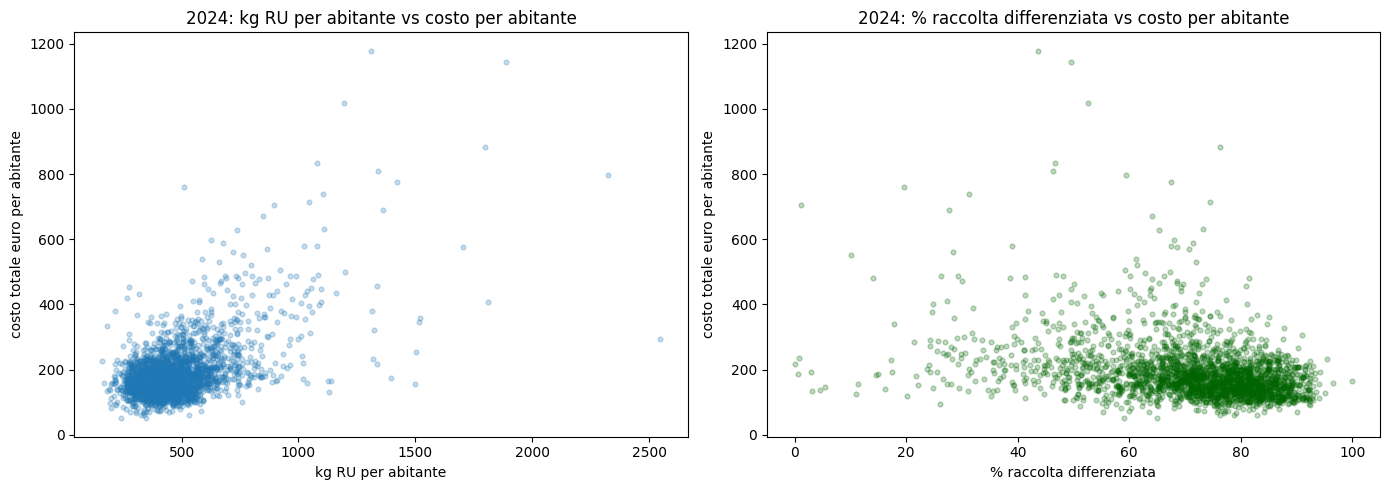

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = joined_2024.sample(min(len(joined_2024), 2500), random_state=42)

axes[0].scatter(sample['kg_ru_per_abitante_calc'], sample['costo_totale_euro_ab'], alpha=0.25, s=12)
axes[0].set_title('2024: kg RU per abitante vs costo per abitante')
axes[0].set_xlabel('kg RU per abitante')
axes[0].set_ylabel('costo totale euro per abitante')

axes[1].scatter(sample['percentuale_rd'], sample['costo_totale_euro_ab'], alpha=0.25, s=12, color='darkgreen')
axes[1].set_title('2024: % raccolta differenziata vs costo per abitante')
axes[1].set_xlabel('% raccolta differenziata')
axes[1].set_ylabel('costo totale euro per abitante')

plt.tight_layout()
plt.show()


La prima immagine mostra un segnale abbastanza leggibile: all'aumentare dei `kg RU per abitante`, tende ad aumentare anche il `costo per abitante`. La seconda relazione e meno netta: la `% RD` non sembra spiegare da sola il livello di costo, almeno non in questo perimetro e senza altri controlli.


## Alcuni outlier leggibili

In questa fase conviene guardare pochi casi, senza trattarli ancora come ranking definitivo.


In [6]:
top_costi = joined_2024[
    ['regione', 'provincia', 'comune', 'kg_ru_per_abitante_calc', 'percentuale_rd', 'costo_totale_euro_ab']
].sort_values('costo_totale_euro_ab', ascending=False).head(10)

top_costi


,regione,provincia,comune,kg_ru_per_abitante_calc,percentuale_rd,costo_totale_euro_ab
2159,Lombardia,Bergamo,FOPPOLO,"1,500.24",37.98,"1,478.30"
1982,Liguria,La Spezia,MONTEROSSO AL MARE,"1,442.47",73.87,"1,399.88"
4600,Piemonte,Torino,SAUZE DOULX,"1,831.53",50.12,"1,268.45"
1878,Liguria,Genova,PORTOFINO,"2,260.14",62.10,"1,236.03"
2380,Lombardia,Brescia,LIMONE SUL GARDA,"3,324.01",67.40,"1,180.45"
4081,Piemonte,Cuneo,ARGENTERA,"1,309.55",43.61,"1,178.22"
4604,Piemonte,Torino,SESTRIERE,"1,886.61",49.60,"1,143.95"
4461,Piemonte,Torino,CLAVIERE,"1,908.36",54.36,"1,062.63"
2279,Lombardia,Bergamo,VALLEVE,799.14,49.98,"1,034.91"
4554,Piemonte,Torino,PRAGELATO,"1,193.88",52.54,"1,017.22"


In [7]:
alti_costi_bassi_kg = joined_2024[
    (joined_2024['kg_ru_per_abitante_calc'] < 400) &
    (joined_2024['costo_totale_euro_ab'] > joined_2024['costo_totale_euro_ab'].quantile(0.95))
][['regione', 'provincia', 'comune', 'kg_ru_per_abitante_calc', 'percentuale_rd', 'costo_totale_euro_ab']].sort_values('costo_totale_euro_ab', ascending=False).head(10)

alti_costi_bassi_kg


,regione,provincia,comune,kg_ru_per_abitante_calc,percentuale_rd,costo_totale_euro_ab
615,Campania,Avellino,PIETRASTORNINA,316.14,62.97,456.79
957,Campania,Salerno,MORIGERATI,274.23,69.30,454.40
3685,Molise,Campobasso,SAN BIASE,316.69,60.78,431.15
366,Calabria,Cosenza,CARPANZANO,266.50,64.52,420.97
100,Abruzzo,LAquila,CAMPO DI GIOVE,216.20,73.14,381.01
1692,Lazio,Roma,CAMERATA NUOVA,322.33,52.43,376.61
953,Campania,Salerno,MONTECORICE,399.56,75.03,375.70
1971,Liguria,La Spezia,CALICE AL CORNOVIGLIO,310.59,82.89,368.93
1759,Lazio,Roma,ROCCA DI CAVE,343.54,59.63,364.41
5420,Sicilia,Palermo,CEFALA DIANA,369.65,70.02,361.85


In [8]:
rd_alta_costo_basso = joined_2024[
    (joined_2024['percentuale_rd'] >= 80) &
    (joined_2024['costo_totale_euro_ab'] <= joined_2024['costo_totale_euro_ab'].quantile(0.35))
][['regione', 'provincia', 'comune', 'kg_ru_per_abitante_calc', 'percentuale_rd', 'costo_totale_euro_ab']].sort_values(['percentuale_rd', 'costo_totale_euro_ab'], ascending=[False, True]).head(10)

rd_alta_costo_basso


,regione,provincia,comune,kg_ru_per_abitante_calc,percentuale_rd,costo_totale_euro_ab
5390,Sicilia,Messina,SINAGRA,344.20,95.72,145.66
51,Abruzzo,Chieti,PALENA,361.01,95.12,128.67
2297,Lombardia,Brescia,ACQUAFREDDA,585.09,95.09,129.91
5358,Sicilia,Messina,CASTEL DI LUCIO,198.39,94.97,149.43
2904,Lombardia,Mantova,SAN GIOVANNI DEL DOSSO,601.04,94.82,147.35
3671,Molise,Campobasso,MONTEFALCONE NEL SANNIO,330.00,94.30,123.43
2872,Lombardia,Mantova,GAZOLDO DEGLI IPPOLITI,901.38,94.04,127.29
6256,Veneto,Treviso,ZENSON DI PIAVE,457.20,94.02,112.95
3421,Lombardia,Varese,TAINO,401.83,93.98,111.68
2910,Lombardia,Mantova,SUSTINENTE,533.12,93.71,116.90


## Prime evidenze

- il cross `A + B + C` e gia usabile, ma solo su un perimetro joinato esplicito
- tra `2020` e `2024` la copertura del join migliora molto
- nel perimetro joinato `2024`, `kg RU per abitante` e `costo per abitante` si muovono nella stessa direzione con una relazione visibile anche prima di modelli piu forti
- la `% RD` aggiunge informazione, ma qui non sembra bastare da sola per spiegare i costi
- i casi estremi suggeriscono che una futura `v1` dovrebbe distinguere meglio profili territoriali diversi, non solo fare ranking

## Nota metodologica minima

Questa lettura non copre ancora tutto il perimetro RU comunale. Lavora solo sui comuni per cui il join tra dataset base, costi per kg e costi per abitante riesce davvero. I risultati vanno quindi letti come primo test del cross, non come fotografia completa di tutti i comuni italiani.
